# Exploratory Data Analysis

> Note: This dataset contains synthetic data, meaning the transactions were artificially generated to resemble real world transaction data. Patterns found in this EDA should therefore not be taken as real world fraud behaviour but rather as relationships within this dataset. 

## Imports

In [1]:
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import MatplotlibDeprecationWarning
import seaborn as sns

warnings.filterwarnings("ignore", category=MatplotlibDeprecationWarning)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)

## Loading the data

In [2]:
df = pd.read_csv("data/fraudTrain.csv", index_col=0)

df["trans_date_trans_time"] = pd.to_datetime(df["trans_date_trans_time"])
df["dob"] = pd.to_datetime(df["dob"])

print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]}")

Rows: 1,296,675
Columns: 22


In [3]:
df.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,VA,24433,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [4]:
df[[
    "trans_date_trans_time", "category", "amt", "gender",
    "state", "city_pop", "is_fraud"
]].head()

,trans_date_trans_time,category,amt,gender,state,city_pop,is_fraud
0,2019-01-01 00:00:18,misc_net,4.97,F,NC,3495,0
1,2019-01-01 00:00:44,grocery_pos,107.23,F,WA,149,0
2,2019-01-01 00:00:51,entertainment,220.11,M,ID,4154,0
3,2019-01-01 00:01:16,gas_transport,45.00,M,MT,1939,0
4,2019-01-01 00:03:06,misc_pos,41.96,M,VA,99,0


## Data-quality checks

Before plotting anything, we need to check the date range, missing values, duplicated transaction IDs and number of cardholders. This confirms the size and structure of the data.

In [5]:
quality_summary = pd.Series({
    "Start date": df["trans_date_trans_time"].min(),
    "End date": df["trans_date_trans_time"].max(),
    "Transactions": len(df),
    "Cardholders": df["cc_num"].nunique(),
    "Missing values": int(df.isna().sum().sum()),
    "Duplicated transaction IDs": int(df["trans_num"].duplicated().sum()),
    "Fraud cases": int(df["is_fraud"].sum()),
})

quality_summary.to_frame("Value")

,Value
Start date,2019-01-01 00:00:18
End date,2020-06-21 12:13:37
Transactions,1296675
Cardholders,983
Missing values,0
Duplicated transaction IDs,0
Fraud cases,7506


In [6]:
unix_timestamp = pd.to_datetime(df["unix_time"], unit="s")
unix_offset_days = (
    df["trans_date_trans_time"] - unix_timestamp
).dt.total_seconds() / (60 * 60 * 24)

print(
    "Difference between the readable and Unix timestamps:",
    f"{unix_offset_days.min():.0f} to {unix_offset_days.max():.0f} days",
)

Difference between the readable and Unix timestamps: 2556 to 2557 days


This is a difference of about 7 years. Moving forward we will use `trans_date_trans_time` as our date column for this project. 

## Class balance

In [7]:
class_summary = pd.DataFrame({
    "Transactions": df["is_fraud"].value_counts(),
    "Percentage": df["is_fraud"].value_counts(normalize=True) * 100,
}).rename(index={0: "Non-fraud", 1: "Fraud"})

class_summary

,Transactions,Percentage
is_fraud,,
Non-fraud,1289169,99.421135
Fraud,7506,0.578865


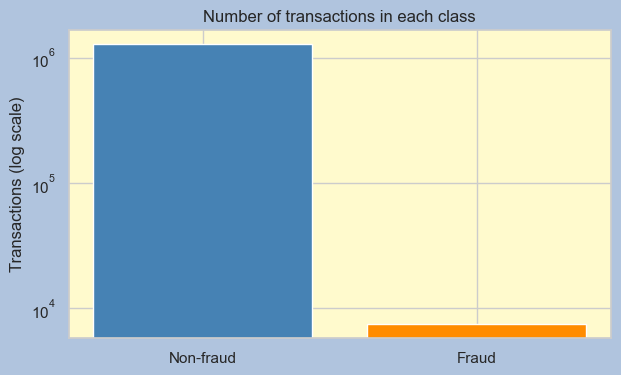

In [8]:
df_class = class_summary.rename_axis("Class").reset_index()

plt.figure(figsize=(7, 4), facecolor='lightsteelblue', edgecolor='blue')

plt.bar(
    df_class["Class"],
    df_class["Transactions"],
    color=["steelblue", "darkorange"]
)

plt.yscale("log")
plt.title("Number of transactions in each class")
plt.xlabel("")
plt.ylabel("Transactions (log scale)")
plt.gca().set_facecolor('lemonchiffon')
plt.show()

Fraud represents only a very small proportion of the data. A model which predicts every transaction as non-fraud would therefore have a very high accuracy while detecting no fraud at all. In model comparison we will therefore focus on the fraud class using average precision, precision, recall and F2 score.

## Transaction amount

In [9]:
amount_summary = (
    df.groupby("is_fraud")["amt"]
    .quantile([0.25, 0.50, 0.75, 0.95])
    .unstack()
    .rename(index={0: "Non-fraud", 1: "Fraud"})
    .rename(columns={0.25: "25%", 0.50: "Median", 0.75: "75%", 0.95: "95%"})
)

amount_summary

,25%,Median,75%,95%
is_fraud,,,,
Non-fraud,9.6100,47.280,82.540,189.900
Fraud,245.6625,396.505,900.875,1083.985


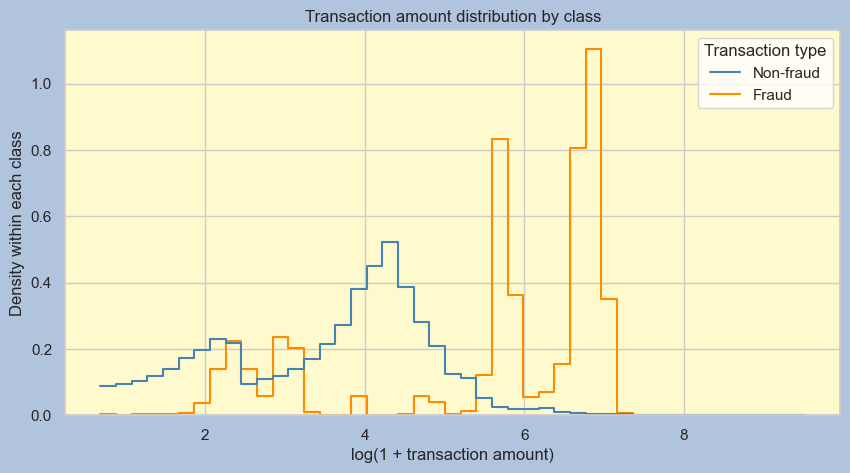

In [10]:
non_fraud_sample = df.loc[df["is_fraud"] == 0].sample(100_000, random_state=42)
amount_plot_data = pd.concat(
    [non_fraud_sample, df.loc[df["is_fraud"] == 1]],
    ignore_index=True,
)
amount_plot_data["Transaction type"] = amount_plot_data["is_fraud"].map(
    {0: "Non-fraud", 1: "Fraud"}
)
amount_plot_data["Log amount"] = np.log1p(amount_plot_data["amt"])

plt.figure(figsize=(10, 5), facecolor='lightsteelblue')
sns.histplot(
    data=amount_plot_data,
    x="Log amount",
    hue="Transaction type",
    hue_order=["Non-fraud", "Fraud"],
    palette={"Non-fraud": "steelblue", "Fraud": "darkorange"},
    stat="density",
    common_norm=False,
    element="step",
    fill=False,
    bins=45,
)
plt.title("Transaction amount distribution by class")
plt.xlabel("log(1 + transaction amount)")
plt.ylabel("Density within each class")
plt.gca().set_facecolor('lemonchiffon')
plt.show()

,amount_band,Transactions,Fraud_cases,Fraud_rate
0,$0-10,"335,718",525,0.16%
1,$10-25,"127,763","1,027",0.80%
2,$25-50,"208,733",55,0.03%
3,$50-100,"389,514",45,0.01%
4,$100-250,"196,488",244,0.12%
5,$250-500,"22,828","1,962",8.59%
6,"$500-1,000","11,694","2,698",23.07%
7,"$1,000+","3,937",950,24.13%


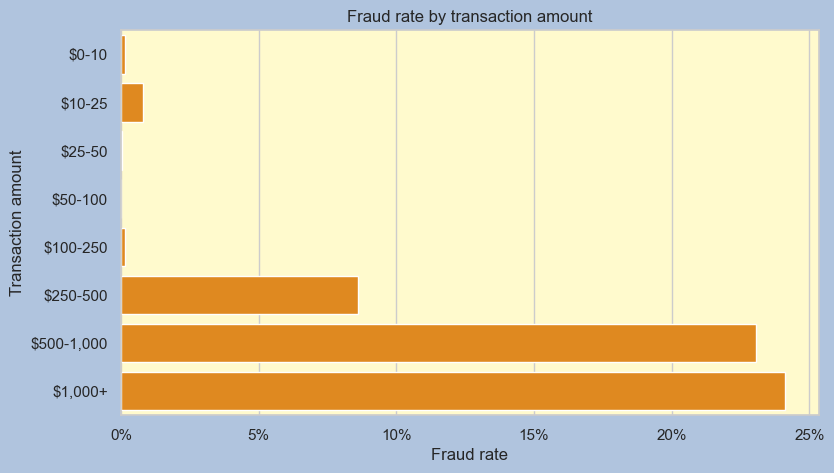

In [11]:
amount_edges = [0, 10, 25, 50, 100, 250, 500, 1_000, np.inf]
amount_labels = [
    "$0-10", "$10-25", "$25-50", "$50-100",
    "$100-250", "$250-500", "$500-1,000", "$1,000+",
]
df["amount_band"] = pd.cut(
    df["amt"], bins=amount_edges, labels=amount_labels, right=False
)

amount_rates = (
    df.groupby("amount_band", observed=False)["is_fraud"]
    .agg(Transactions="size", Fraud_cases="sum", Fraud_rate="mean")
    .reset_index()
)

display(amount_rates.style.format({
    "Transactions": "{:,}",
    "Fraud_cases": "{:,}",
    "Fraud_rate": "{:.2%}",
}))

plt.figure(figsize=(9, 5), facecolor='lightsteelblue')
sns.barplot(data=amount_rates, x="Fraud_rate", y="amount_band", color="darkorange")
plt.title("Fraud rate by transaction amount")
plt.xlabel("Fraud rate")
plt.ylabel("Transaction amount")
plt.gca().xaxis.set_major_formatter(lambda value, position: f"{value:.0%}")
plt.gca().set_facecolor('lemonchiffon')
plt.show()

Fraudulent transactions are not evenly distributed across transaction amounts. They seem to be concentrated above $250, with one small group below $25. Non-fraudulent transactions seem to be concentrated more heavily around the middle. 

We use a log scale for the distribution because amount has a long right tail, but we also keep fixed dollar bands so the result remains easy to interpret. This suggests transaction amount would be an important model feature.

## Cardholder characteristics

,gender,Transactions,Cardholders,Fraud_cases,Fraud_rate
0,F,709863,497,3735,0.005262
1,M,586812,486,3771,0.006426


,age_band,Transactions,Cardholders,Fraud_cases,Fraud_rate
0,Under 25,121663,93,764,0.006280
1,25-34,287689,207,1391,0.004835
2,35-44,272943,192,1163,0.004261
3,45-54,256600,213,1491,0.005811
4,55-64,164081,186,1259,0.007673
5,65-74,100421,106,596,0.005935
6,75+,93278,105,842,0.009027


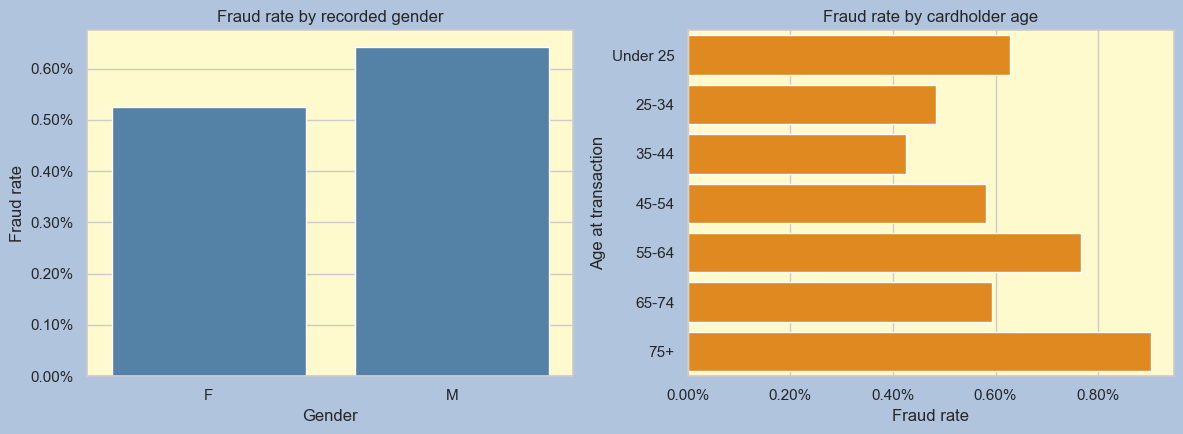

In [12]:
birthday_has_passed = (
    (df["trans_date_trans_time"].dt.month > df["dob"].dt.month)
    | (
        (df["trans_date_trans_time"].dt.month == df["dob"].dt.month)
        & (df["trans_date_trans_time"].dt.day >= df["dob"].dt.day)
    )
)

df["age"] = (
    df["trans_date_trans_time"].dt.year
    - df["dob"].dt.year
    - (~birthday_has_passed).astype(int)
)

age_edges = [0, 25, 35, 45, 55, 65, 75, 111]
age_labels = ["Under 25", "25-34", "35-44", "45-54", "55-64", "65-74", "75+"]
df["age_band"] = pd.cut(df["age"], bins=age_edges, labels=age_labels, right=False)

gender_rates = (
    df.groupby("gender")
    .agg(
        Transactions=("is_fraud", "size"),
        Cardholders=("cc_num", "nunique"),
        Fraud_cases=("is_fraud", "sum"),
        Fraud_rate=("is_fraud", "mean"),
    )
    .reset_index()
)
age_rates = (
    df.groupby("age_band", observed=False)
    .agg(
        Transactions=("is_fraud", "size"),
        Cardholders=("cc_num", "nunique"),
        Fraud_cases=("is_fraud", "sum"),
        Fraud_rate=("is_fraud", "mean"),
    )
    .reset_index()
)

display(gender_rates)
display(age_rates)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), facecolor="lightsteelblue"
)
sns.barplot(data=gender_rates, x="gender", y="Fraud_rate", color="steelblue", ax=axes[0])
axes[0].set_title("Fraud rate by recorded gender")
axes[0].set_xlabel("Gender")
axes[0].set_ylabel("Fraud rate")
axes[0].yaxis.set_major_formatter(lambda value, position: f"{value:.2%}")
axes[0].set_facecolor('lemonchiffon')

sns.barplot(data=age_rates, x="Fraud_rate", y="age_band", color="darkorange", ax=axes[1])
axes[1].set_title("Fraud rate by cardholder age")
axes[1].set_xlabel("Fraud rate")
axes[1].set_ylabel("Age at transaction")
axes[1].xaxis.set_major_formatter(lambda value, position: f"{value:.2%}")
axes[1].set_facecolor('lemonchiffon')

plt.tight_layout()
plt.show()

Age is calculated at the transaction date rather than from the current year. The rates differ across groups, but these are repeated transactions from a synthetic population and do not show that age or gender causes fraud. We will keep both variables for EDA and possible subgroup analysis but leave them out of model training.

## Transaction time

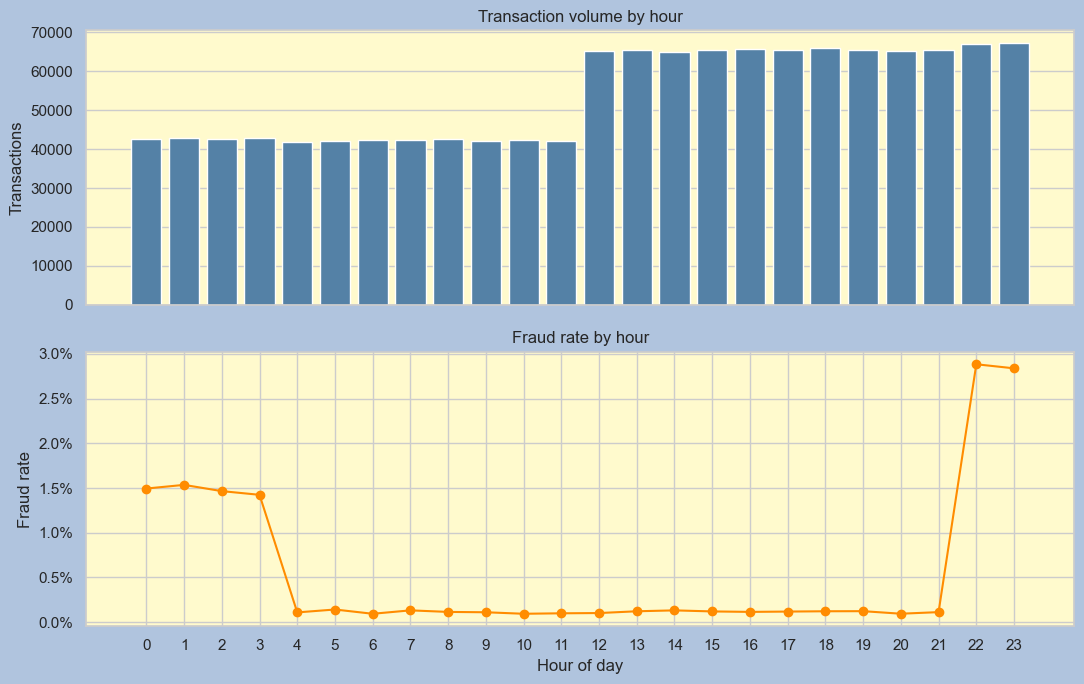

In [13]:
df["transaction_hour"] = df["trans_date_trans_time"].dt.hour
df["weekday"] = df["trans_date_trans_time"].dt.day_name()
df["year_month"] = df["trans_date_trans_time"].dt.to_period("M").astype(str)

hourly = (
    df.groupby("transaction_hour")["is_fraud"]
    .agg(Transactions="size", Fraud_cases="sum", Fraud_rate="mean")
    .reset_index()
)

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True, facecolor = 'lightsteelblue')
sns.barplot(data=hourly, x="transaction_hour", y="Transactions", color="steelblue", ax=axes[0])
axes[0].set_title("Transaction volume by hour")
axes[0].set_xlabel("")
axes[0].set_ylabel("Transactions")
axes[0].set_facecolor('lemonchiffon')

axes[1].plot(
    hourly["transaction_hour"].to_numpy(),
    hourly["Fraud_rate"].to_numpy(),
    marker="o",
    color="darkorange",
)
axes[1].set_title("Fraud rate by hour")
axes[1].set_xlabel("Hour of day")
axes[1].set_ylabel("Fraud rate")
axes[1].set_xticks(range(24))
axes[1].yaxis.set_major_formatter(lambda value, position: f"{value:.1%}")
axes[1].set_facecolor('lemonchiffon')

plt.tight_layout()
plt.show()

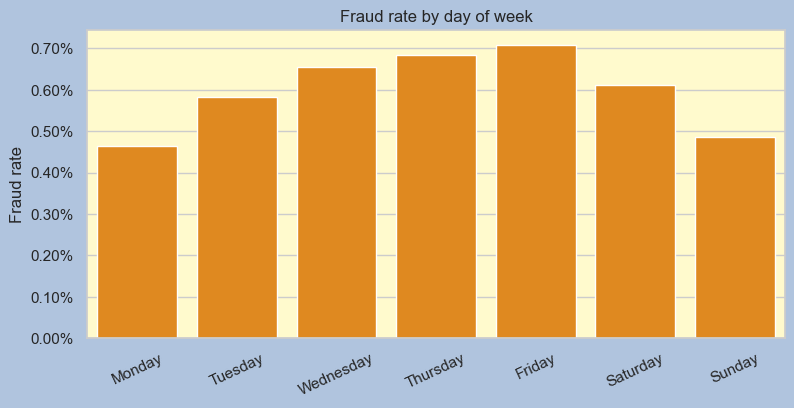

In [14]:
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_rates = (
    df.groupby("weekday")["is_fraud"]
    .agg(Transactions="size", Fraud_cases="sum", Fraud_rate="mean")
    .reindex(weekday_order)
    .reset_index()
)

plt.figure(figsize=(9, 4), facecolor='lightsteelblue')
sns.barplot(data=weekday_rates, x="weekday", y="Fraud_rate", color="darkorange")
plt.title("Fraud rate by day of week")
plt.xlabel("")
plt.ylabel("Fraud rate")
plt.xticks(rotation=25)
plt.gca().yaxis.set_major_formatter(lambda value, position: f"{value:.2%}")
plt.gca().set_facecolor('lemonchiffon')
plt.show()

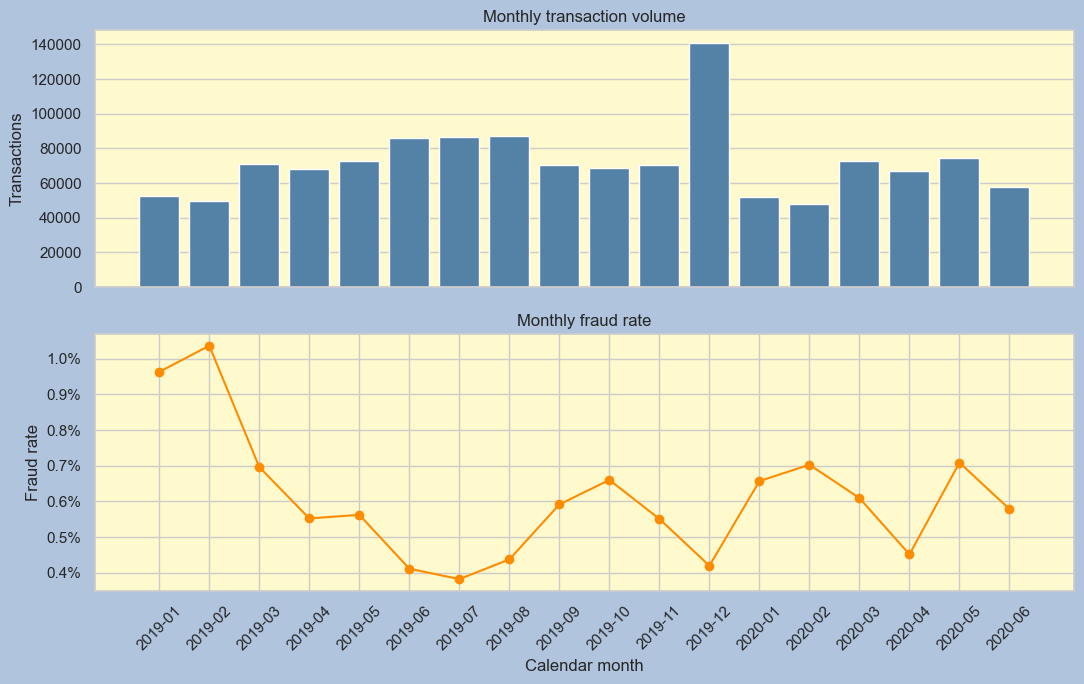

In [15]:
monthly = (
    df.groupby("year_month")["is_fraud"]
    .agg(Transactions="size", Fraud_cases="sum", Fraud_rate="mean")
    .reset_index()
)

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True, facecolor = 'lightsteelblue')
sns.barplot(data=monthly, x="year_month", y="Transactions", color="steelblue", ax=axes[0])
axes[0].set_title("Monthly transaction volume")
axes[0].set_xlabel("")
axes[0].set_ylabel("Transactions")
axes[0].set_facecolor('lemonchiffon')

axes[1].plot(
    monthly["year_month"].to_numpy(),
    monthly["Fraud_rate"].to_numpy(),
    marker="o",
    color="darkorange",
)
axes[1].set_title("Monthly fraud rate")
axes[1].set_xlabel("Calendar month")
axes[1].set_ylabel("Fraud rate")
axes[1].tick_params(axis="x", rotation=45)
axes[1].yaxis.set_major_formatter(lambda value, position: f"{value:.1%}")
axes[1].set_facecolor('lemonchiffon')

plt.tight_layout()
plt.show()

Fraud seems to be much more common late at night, specifically between 22:00 and 03:00. The differences across days of the week are smaller. Monthly fraud rates also vary over time, with the highest rates occurring at the beginning of 2019. The final June 2020 period is incomplete, so its transaction volume should not be compared directly with a full month.

## Merchant category

,category,Transactions,Fraud_cases,Fraud_rate
0,health_fitness,85879,133,0.001549
1,home,123115,198,0.001608
2,food_dining,91461,151,0.001651
3,kids_pets,113035,239,0.002114
4,personal_care,90758,220,0.002424
5,entertainment,94014,233,0.002478
6,travel,40507,116,0.002864
7,grocery_net,45452,134,0.002948
8,misc_pos,79655,250,0.003139
9,gas_transport,131659,618,0.004694


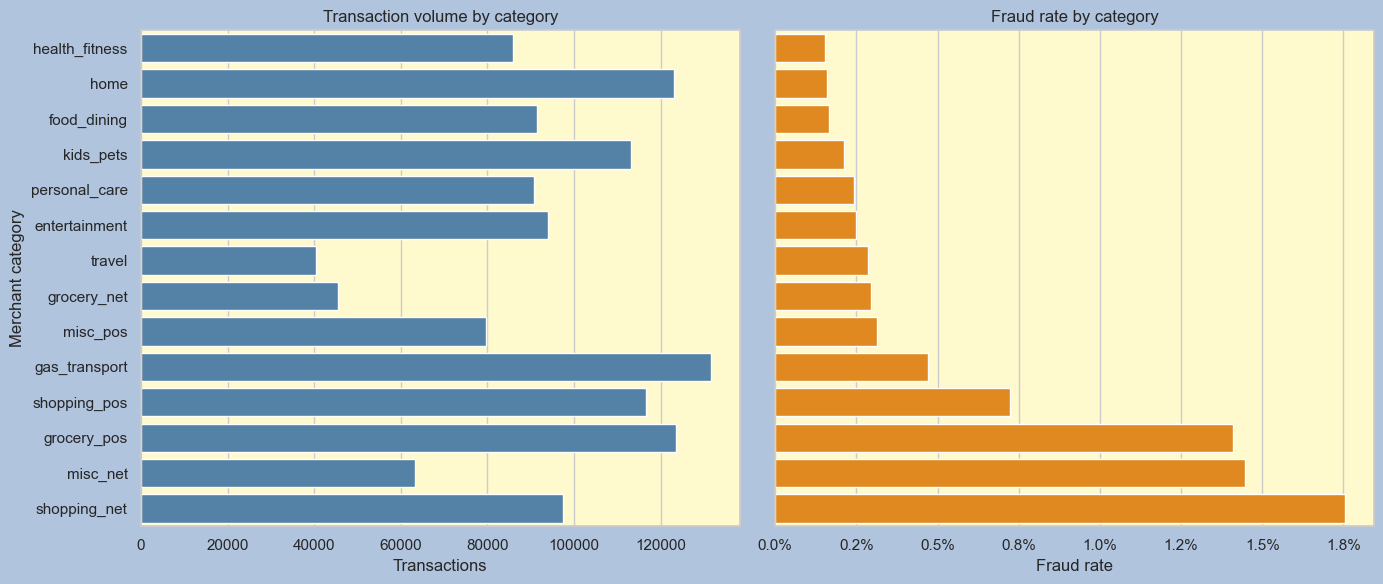

In [16]:
category_summary = (
    df.groupby("category")["is_fraud"]
    .agg(Transactions="size", Fraud_cases="sum", Fraud_rate="mean")
    .sort_values("Fraud_rate")
    .reset_index()
)

display(category_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True, facecolor='lightsteelblue')
sns.barplot(data=category_summary, x="Transactions", y="category", color="steelblue", ax=axes[0])
axes[0].set_title("Transaction volume by category")
axes[0].set_xlabel("Transactions")
axes[0].set_ylabel("Merchant category")
axes[0].set_facecolor('lemonchiffon')

sns.barplot(data=category_summary, x="Fraud_rate", y="category", color="darkorange", ax=axes[1])
axes[1].set_title("Fraud rate by category")
axes[1].set_xlabel("Fraud rate")
axes[1].set_ylabel("")
axes[1].set_facecolor('lemonchiffon')
axes[1].xaxis.set_major_formatter(lambda value, position: f"{value:.1%}")


plt.tight_layout()
plt.show()

The left shows transaction volume, while the right shows the observed fraud rate within each category. Gas transport has the highest transaction volume but a fraud rate of only 0.47%. Online shopping has a lower volume but the highest fraud rate at 1.76%. This shows why raw fraud counts can be misleading when categories contain different numbers of transactions. Merchant category therefore is informative and will be used for modelling.

## Geography

,median,mean,std
is_fraud,,,
Non-fraud,78.233012,76.113756,29.119051
Fraud,77.931954,76.268330,28.752602


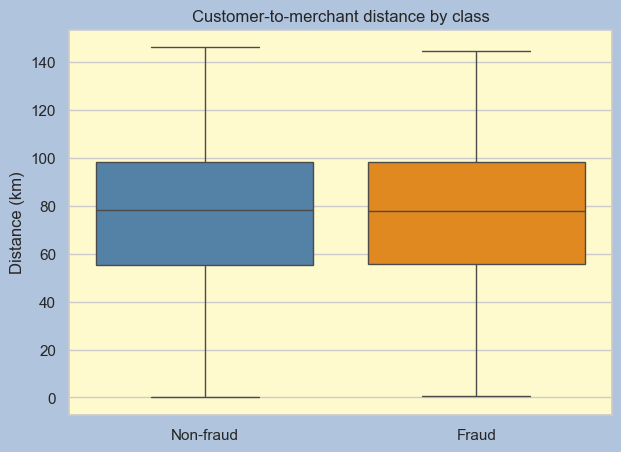

In [17]:
customer_latitude = np.radians(df["lat"])
customer_longitude = np.radians(df["long"])
merchant_latitude = np.radians(df["merch_lat"])
merchant_longitude = np.radians(df["merch_long"])

latitude_difference = merchant_latitude - customer_latitude
longitude_difference = merchant_longitude - customer_longitude

haversine_value = (
    np.sin(latitude_difference / 2) ** 2
    + np.cos(customer_latitude)
    * np.cos(merchant_latitude)
    * np.sin(longitude_difference / 2) ** 2
)
df["distance_km"] = 6371 * 2 * np.arcsin(np.sqrt(haversine_value))

distance_summary = (
    df.groupby("is_fraud")["distance_km"]
    .agg(["median", "mean", "std"])
    .rename(index={0: "Non-fraud", 1: "Fraud"})
)
display(distance_summary)

distance_plot_data = pd.concat([
    df.loc[df["is_fraud"] == 0].sample(50_000, random_state=42),
    df.loc[df["is_fraud"] == 1],
])
distance_plot_data["Transaction type"] = distance_plot_data["is_fraud"].map(
    {0: "Non-fraud", 1: "Fraud"}
)

plt.figure(figsize=(7, 5), facecolor='lightsteelblue')
sns.boxplot(
    data=distance_plot_data,
    x="Transaction type",
    y="distance_km",
    hue="Transaction type",
    palette={"Non-fraud": "steelblue", "Fraud": "darkorange"},
    legend=False,
    showfliers=False,
)
plt.title("Customer-to-merchant distance by class")
plt.xlabel("")
plt.ylabel("Distance (km)")
plt.gca().set_facecolor('lemonchiffon')
plt.show()

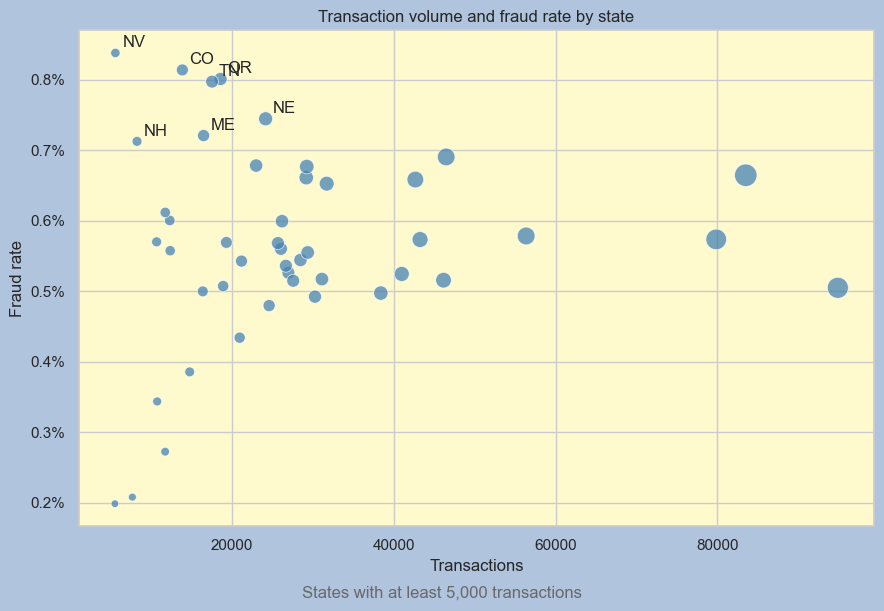

In [18]:
state_summary = (
    df.groupby("state")["is_fraud"]
    .agg(Transactions="size", Fraud_cases="sum", Fraud_rate="mean")
    .reset_index()
)
state_plot_data = state_summary[state_summary["Transactions"] >= 5_000].copy()
states_to_label = state_plot_data.nlargest(7, "Fraud_rate")

plt.figure(figsize=(9, 6), facecolor='lightsteelblue')
sns.scatterplot(
    data=state_plot_data,
    x="Transactions",
    y="Fraud_rate",
    size="Fraud_cases",
    sizes=(30, 260),
    color="steelblue",
    alpha=0.75,
    legend=False,
)
for _, row in states_to_label.iterrows():
    plt.annotate(row["state"], (row["Transactions"], row["Fraud_rate"]), xytext=(5, 4), textcoords="offset points")

plt.title("Transaction volume and fraud rate by state")
plt.xlabel("Transactions")
plt.ylabel("Fraud rate")
plt.gca().yaxis.set_major_formatter(lambda value, position: f"{value:.1%}")
plt.figtext(0.5, -0.01, "States with at least 5,000 transactions", ha="center", color="dimgray")
plt.tight_layout()
plt.gca().set_facecolor('lemonchiffon')
plt.show()

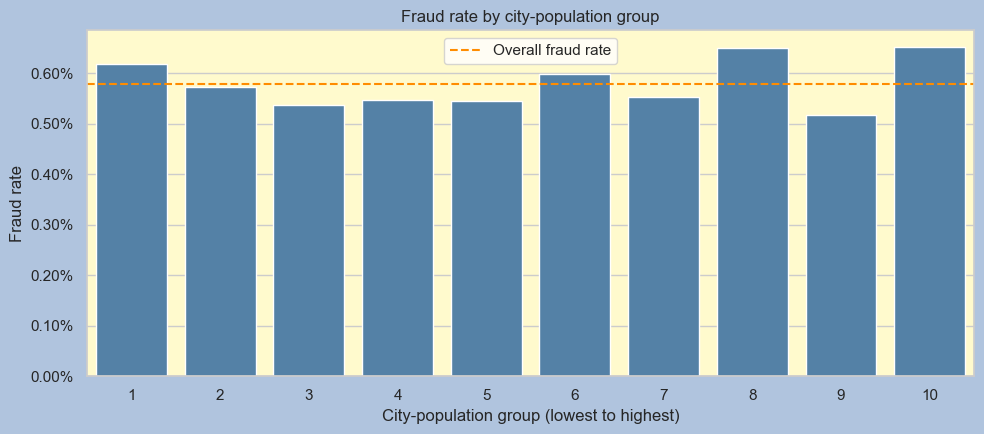

In [19]:
df["city_population_group"] = pd.qcut(
    df["city_pop"],
    q=10,
    labels=range(1, 11),
    duplicates="drop",
)
city_population_rates = (
    df.groupby("city_population_group", observed=False)["is_fraud"]
    .agg(Transactions="size", Fraud_cases="sum", Fraud_rate="mean")
    .reset_index()
)

plt.figure(figsize=(10, 4.5), facecolor='lightsteelblue')
sns.barplot(
    data=city_population_rates,
    x="city_population_group",
    y="Fraud_rate",
    color="steelblue",
)
plt.axhline(df["is_fraud"].mean(), color="darkorange", linestyle="--", label="Overall fraud rate")
plt.title("Fraud rate by city-population group")
plt.xlabel("City-population group (lowest to highest)")
plt.ylabel("Fraud rate")
plt.gca().yaxis.set_major_formatter(lambda value, position: f"{value:.2%}")
plt.legend()
plt.tight_layout()
plt.gca().set_facecolor('lemonchiffon')
plt.show()

Customer-to-merchant distance is distributed very similarly across the two classes, while city-population groups remain close to the overall fraud rate and show no clear trend. Neither of these appears very informative. We keep them as weaker numerical candidates. State-level fraud rates vary more, especially among lower-volume states, but including state could encourage the model to learn simulator-specific regional patterns. Hence we leave state out of model training.

## Interaction between category and amount

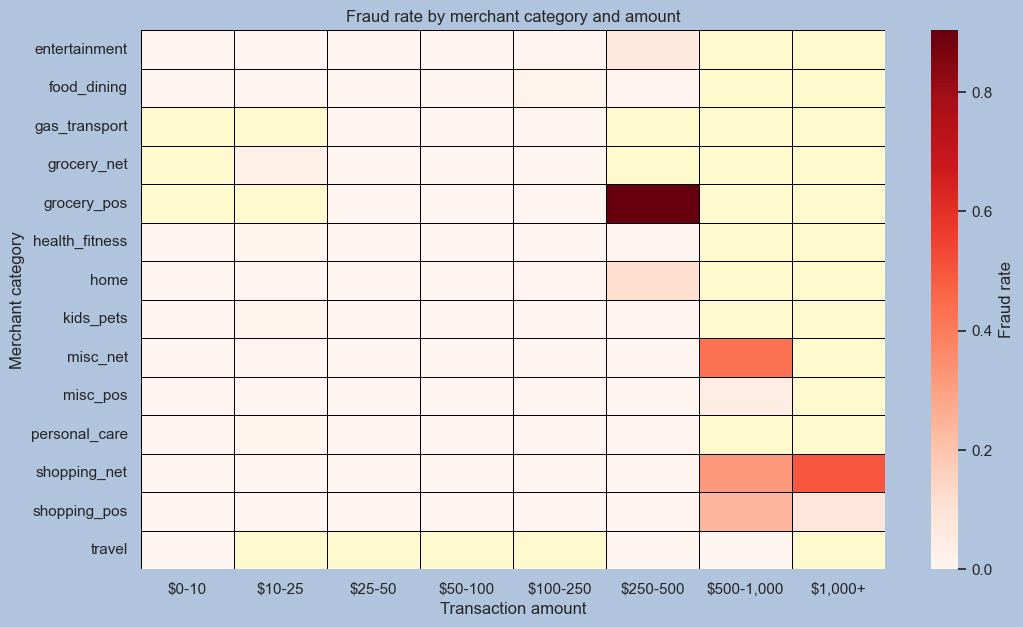

In [20]:
interaction = (
    df.groupby(["category", "amount_band"], observed=False)["is_fraud"]
    .agg(Transactions="size", Fraud_rate="mean")
    .reset_index()
)

# Very small groups can produce unstable rates, so they are left blank
interaction.loc[interaction["Transactions"] < 500, "Fraud_rate"] = np.nan
interaction_matrix = interaction.pivot(
    index="category", columns="amount_band", values="Fraud_rate"
)

plt.figure(figsize=(12, 7), facecolor='lightsteelblue')
sns.heatmap(
    interaction_matrix,
    cmap='Reds',
    linewidths=0.4,
    linecolor="black",
    cbar_kws={"label": "Fraud rate"},
)
plt.title("Fraud rate by merchant category and amount")
plt.xlabel("Transaction amount")
plt.ylabel("Merchant category")
plt.grid(False)
plt.gca().set_facecolor('lemonchiffon')
plt.show()

This heatmap shows the fraud rate for each combination of merchant category and transaction amount band. Darker cells indicate a higher observed fraud rate, while white cells contain fewer than 500 transactions and are not displayed. 

The same amount range can have very different fraud rates depending on the merchant category. This suggests that category and amount interact, so tree-based models may be useful because they can learn these combinations without manually creating a feature for every possible pair.

## Cardholder history

In [21]:
history = df[[
    "trans_date_trans_time", "trans_num", "cc_num", "amt", "is_fraud"
]].sort_values(["trans_date_trans_time", "trans_num"], kind="mergesort").copy()

# Build one row for each cardholder and timestamp
# Transactions recorded at the same moment therefore receive exactly the same earlier history
cardholder_time = (
    history.groupby(["cc_num", "trans_date_trans_time"], as_index=False)
    .agg(Amount_at_time=("amt", "sum"), Transactions_at_time=("amt", "size"))
    .sort_values(["cc_num", "trans_date_trans_time"], kind="mergesort")
)
by_cardholder = cardholder_time.groupby("cc_num", sort=False)

cardholder_time["Prior_transaction_count"] = (
    by_cardholder["Transactions_at_time"].cumsum()
    - cardholder_time["Transactions_at_time"]
)
cardholder_time["Prior_amount_sum"] = (
    by_cardholder["Amount_at_time"].cumsum()
    - cardholder_time["Amount_at_time"]
)
cardholder_time["Prior_mean_amount"] = (
    cardholder_time["Prior_amount_sum"]
    / cardholder_time["Prior_transaction_count"].replace(0, np.nan)
)
cardholder_time["Previous_transaction_time"] = (
    by_cardholder["trans_date_trans_time"].shift()
)

history = history.merge(
    cardholder_time[[
        "cc_num", "trans_date_trans_time", "Prior_transaction_count",
        "Prior_mean_amount", "Previous_transaction_time",
    ]],
    on=["cc_num", "trans_date_trans_time"],
    how="left",
    validate="many_to_one",
)

history["Hours_since_previous"] = (
    history["trans_date_trans_time"] - history["Previous_transaction_time"]
).dt.total_seconds() / 3600
history["Amount_to_prior_mean"] = history["amt"] / history["Prior_mean_amount"]

,Amount_comparison,Transactions,Fraud_cases,Fraud_rate
0,Under 0.5x,544741,1589,0.002917
1,0.5-1x,327285,204,0.000623
2,1-2x,287780,408,0.001418
3,2-5x,111329,1374,0.012342
4,Over 5x,24557,3856,0.157022


,Time_since_previous,Transactions,Fraud_cases,Fraud_rate
0,Under 1h,212547,3266,0.015366
1,1-6h,534325,2023,0.003786
2,6-24h,440884,1918,0.004350
3,1-3 days,98495,208,0.002112
4,3-7 days,9156,14,0.001529
5,Over 7 days,285,2,0.007018


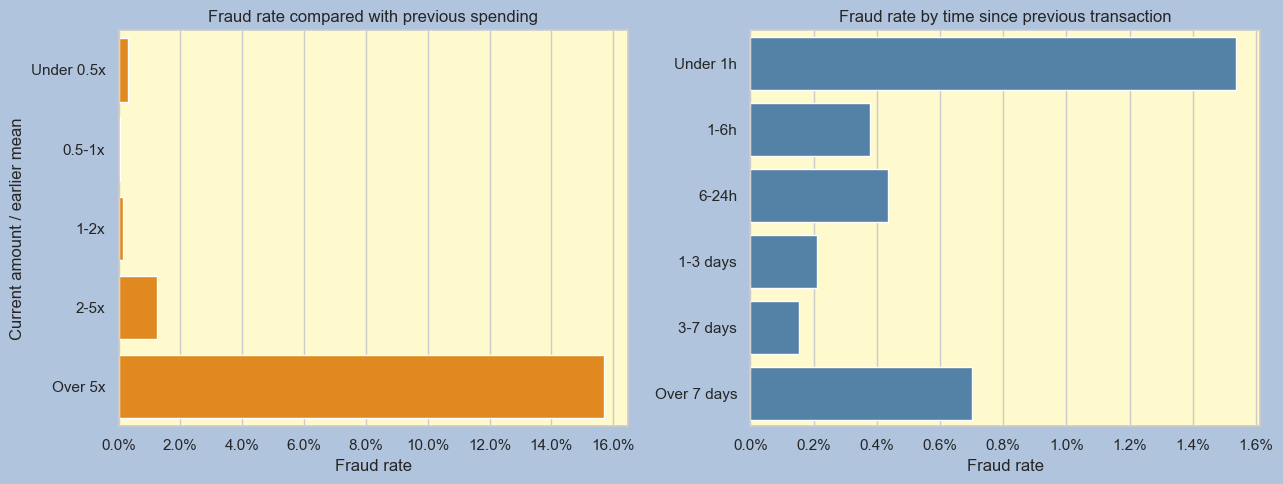

In [22]:
history_with_previous = history[history["Prior_transaction_count"] > 0].copy()

history_with_previous["Amount_comparison"] = pd.cut(
    history_with_previous["Amount_to_prior_mean"],
    bins=[0, 0.5, 1, 2, 5, np.inf],
    labels=["Under 0.5x", "0.5-1x", "1-2x", "2-5x", "Over 5x"],
)
history_with_previous["Time_since_previous"] = pd.cut(
    history_with_previous["Hours_since_previous"],
    bins=[0, 1, 6, 24, 72, 168, np.inf],
    labels=["Under 1h", "1-6h", "6-24h", "1-3 days", "3-7 days", "Over 7 days"],
    include_lowest=True,
)

amount_history_rates = (
    history_with_previous.groupby("Amount_comparison", observed=False)["is_fraud"]
    .agg(Transactions="size", Fraud_cases="sum", Fraud_rate="mean")
    .reset_index()
)
time_history_rates = (
    history_with_previous.groupby("Time_since_previous", observed=False)["is_fraud"]
    .agg(Transactions="size", Fraud_cases="sum", Fraud_rate="mean")
    .reset_index()
)

display(amount_history_rates)
display(time_history_rates)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor='lightsteelblue')
sns.barplot(data=amount_history_rates, x="Fraud_rate", y="Amount_comparison", color="darkorange", ax=axes[0])
axes[0].set_title("Fraud rate compared with previous spending")
axes[0].set_xlabel("Fraud rate")
axes[0].set_ylabel("Current amount / earlier mean")
axes[0].xaxis.set_major_formatter(lambda value, position: f"{value:.1%}")
axes[0].set_facecolor('lemonchiffon')

sns.barplot(data=time_history_rates, x="Fraud_rate", y="Time_since_previous", color="steelblue", ax=axes[1])
axes[1].set_title("Fraud rate by time since previous transaction")
axes[1].set_xlabel("Fraud rate")
axes[1].set_ylabel("")
axes[1].set_facecolor('lemonchiffon')
axes[1].xaxis.set_major_formatter(lambda value, position: f"{value:.1%}")

plt.tight_layout()
plt.show()

These features compare each transaction with the cardholder’s own earlier activity. Transactions over five times the cardholder’s previous average have a much higher observed fraud rate, while transactions made within one hour of the previous transaction also appear more likely to be fraudulent. 

The result for gaps over seven days should not be interpreted strongly because that group contains only 285 transactions. Only information from strictly earlier transactions is used, preventing future information from leaking into the features. The card number is used only to group each cardholder’s transaction history and is removed before training.

## Feature plan from the EDA

The analysis leads to a focused feature set:

- log-transformed transaction amount
- raw and cyclical hour, weekday and month features
- one-hot encoded merchant category
- log-transformed time since the previous transaction
- current amount compared with the cardholder's earlier mean
- log-transformed city population and customer-to-merchant distance as initial numerical candidates

Transaction amount, transaction time, merchant category and the two cardholder-history measures show the clearest patterns in the EDA. City population and distance show little separation by themselves, so we keep them as weaker numerical candidates.

Age and gender are examined in the EDA but are left out of model training. Date of birth, names, addresses, job title, merchant name and transaction ID are also left out. State is excluded because it may encourage the model to learn simulator-specific regional patterns. Card number is used only to construct the history features and is removed before training.

The next notebook builds these features directly and checks that only earlier transactions contribute to the history variables.